<a href="https://www.kaggle.com/code/riteshkumarweb/ridge-regression?scriptVersionId=310275240" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/nikhil7280/student-performance-multiple-linear-regression/Student_Performance.csv


In [ ]:
"""Linear regression might produce coefficients like:

Hours Studied coefficient = 12
Sleep coefficient = -8
Previous Score coefficient = 15

This means:

1 extra study hour → +12 performance
1 extra sleep hour → -8 performance

This is unrealistic and unstable.

Why?

The model is overfitting the training data.

📊 After Applying Ridge

The model might become:

Hours coefficient = 4.5
Sleep coefficient = 2.1
Previous score coefficient = 6.0

Now the interpretation becomes reasonable:

More study → better performance
More sleep → slightly better performance

The model becomes more stable"""

In [2]:
df = pd.read_csv('/kaggle/input/datasets/nikhil7280/student-performance-multiple-linear-regression/Student_Performance.csv')

In [3]:
df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


In [4]:
new_df = df.drop(columns='Extracurricular Activities')

In [5]:
new_df

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,9,1,91.0
1,4,82,4,2,65.0
2,8,51,7,2,45.0
3,5,52,5,2,36.0
4,7,75,8,5,66.0
...,...,...,...,...,...
9995,1,49,4,2,23.0
9996,7,64,8,5,58.0
9997,6,83,8,5,74.0
9998,9,97,7,0,95.0


In [6]:
X = new_df.iloc[:,0:-1]
X
y = new_df.iloc[:,-1]

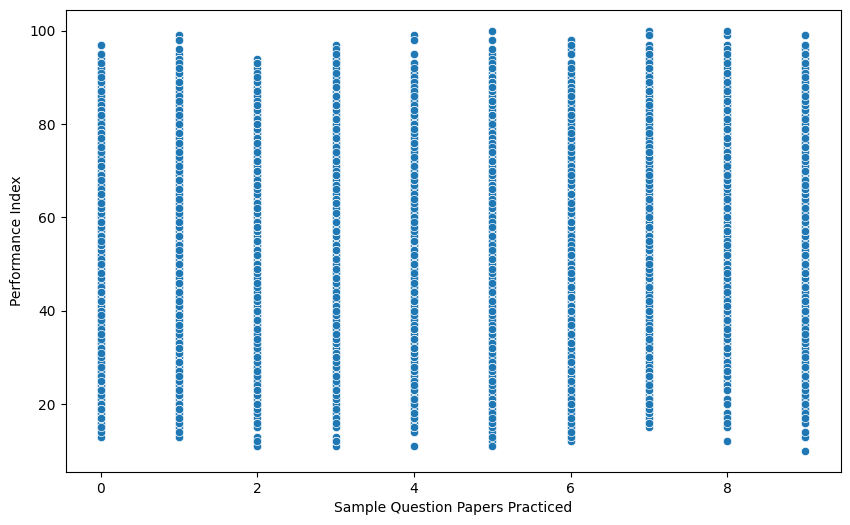

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('/kaggle/input/datasets/nikhil7280/student-performance-multiple-linear-regression/Student_Performance.csv')
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Sample Question Papers Practiced', y='Performance Index', data=df)
plt.show()

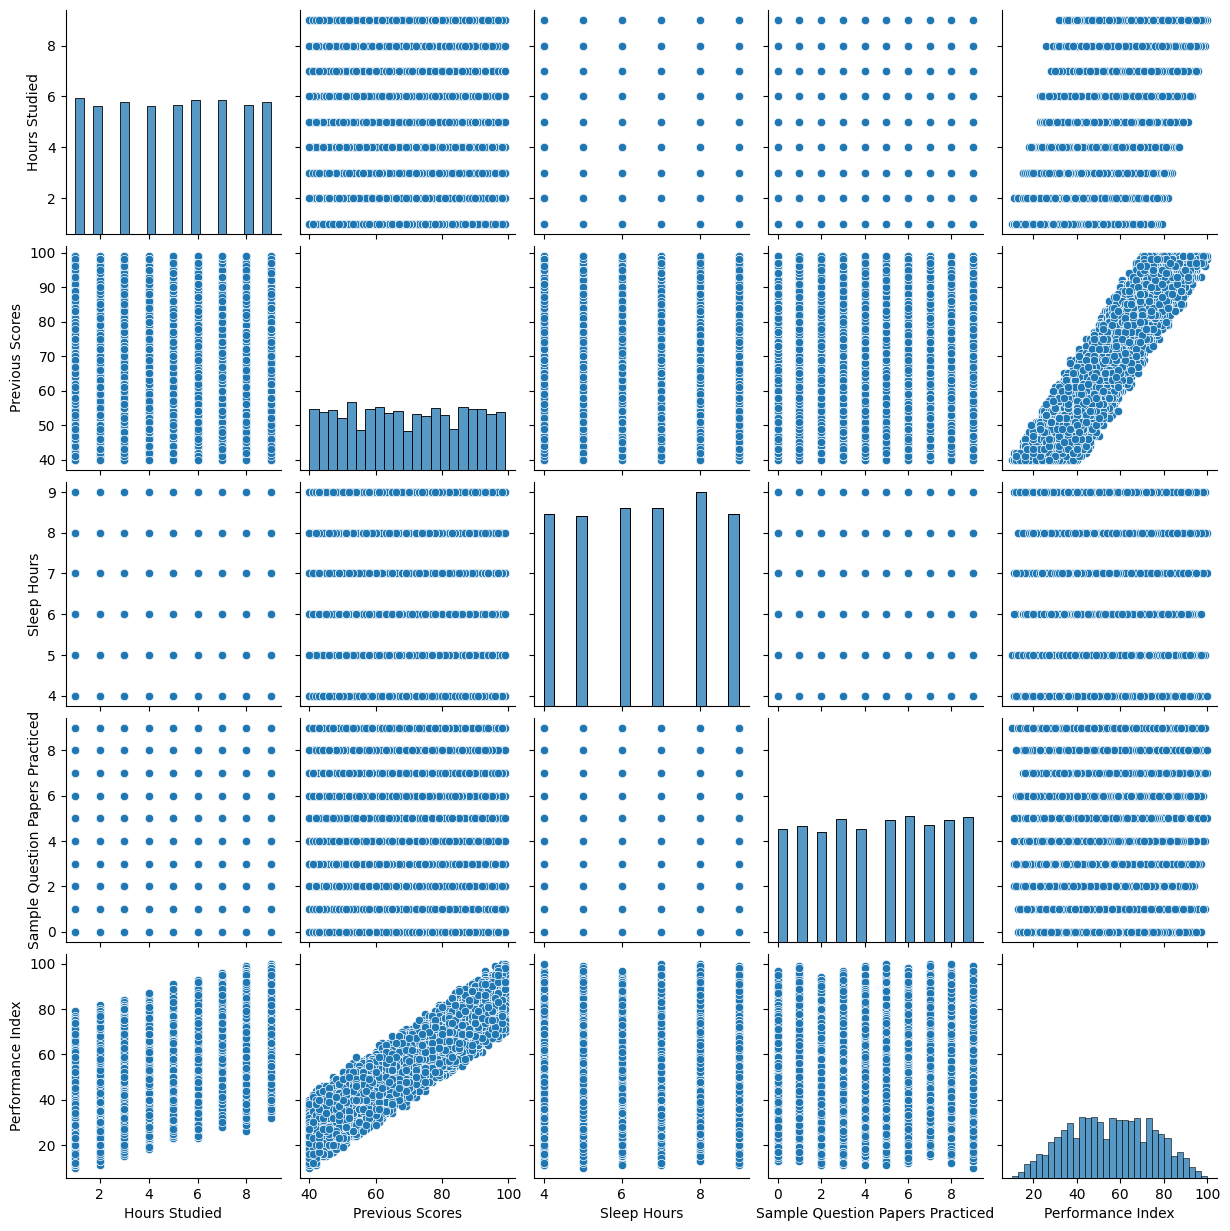

In [8]:
sns.pairplot(new_df)

In [9]:
from sklearn.model_selection import train_test_split

# X = features, y = target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,    # 20% of data for testing, 80% for training
    random_state=42,  # Seed for reproducibility (ensures same split each time) 
)

In [10]:
y_train

9254    36.0
1561    25.0
1670    59.0
6087    22.0
6669    40.0
        ... 
5734    48.0
5191    51.0
5390    44.0
860     20.0
7270    24.0
Name: Performance Index, Length: 8000, dtype: float64

In [11]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
# 2. Initialize and train the model
model.fit(X_train, y_train)

LinearRegression()

In [12]:
y_predict = model.predict(X_test)

In [13]:
from sklearn.metrics import r2_score, mean_squared_error
# R2 Score
r2 = r2_score(y_test, y_predict)
print(r2)

0.9887144552384186


In [14]:
# RMSE
# Note: For sklearn < 1.4, use squared=False in mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test, y_predict))
print(rmse)

2.045056213064525


In [15]:
# 📦 Import Ridge Regression model from sklearn
# Ridge is a regularized version of Linear Regression
# It helps prevent overfitting by adding a penalty to large coefficients
from sklearn.linear_model import Ridge


# 🧠 Create a Ridge Regression model
# alpha = regularization strength
# Larger alpha → stronger penalty on coefficients
ridge_model = Ridge(alpha=1)


# 🎯 Train (fit) the Ridge model using training data
# The model learns the relationship between X_train and y_train
ridge_model.fit(X_train, y_train)


# 🔮 Make predictions using the trained Ridge model
# X_test → unseen data
# The model predicts the output values
y_redge_predict = ridge_model.predict(X_test)


# 📊 Calculate the R² score (model performance metric)
# This compares predicted values vs actual values
r2 = r2_score(y_test, y_redge_predict)


# 🖨️ Print the R² score
r2

0.9887144377403252

In [16]:
# 📊 Calculate RMSE (Root Mean Squared Error)
# RMSE measures how far the predicted values are from the actual values

# 🧮 mean_squared_error(y_test, y_redge_predict)
# Step 1: Calculate MSE (Mean Squared Error)
# This computes the average of the squared differences between
# the actual values and the predicted values

# 🔢 np.sqrt(...)
# Step 2: Take the square root of the MSE
# This converts the error back to the original unit of the target variable

rmse = np.sqrt(mean_squared_error(y_test, y_redge_predict))


# 🖨️ Print the RMSE value
# Smaller RMSE → better model performance
print(rmse)

2.045057798480722
